# **SVM (Support Vector Machine)**

**Check this link for Geometric Intuition of SVM** : https://youtu.be/ugTxMLjLS8M?si=ueqNfUj1LKHGksk6&t=355

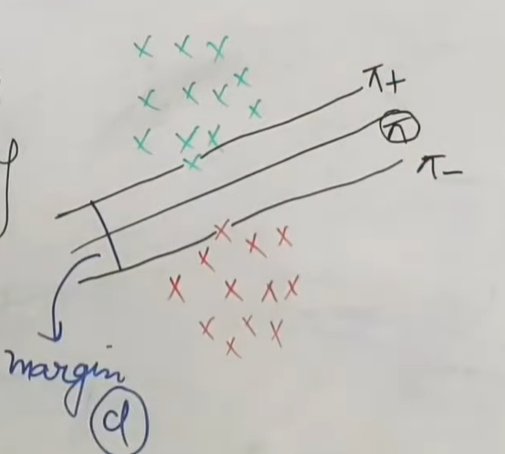

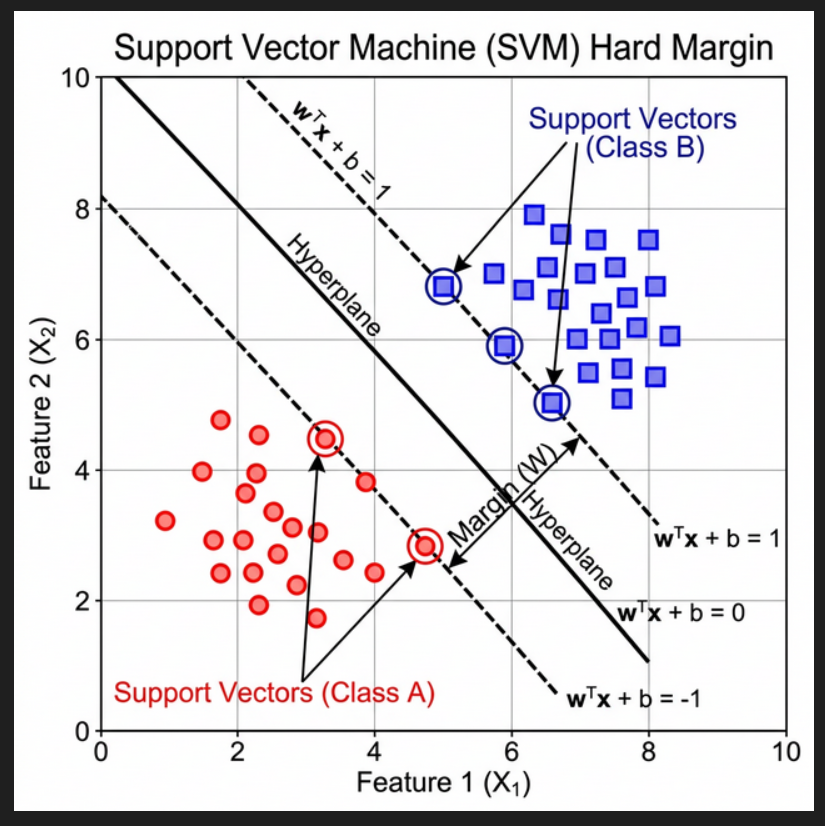

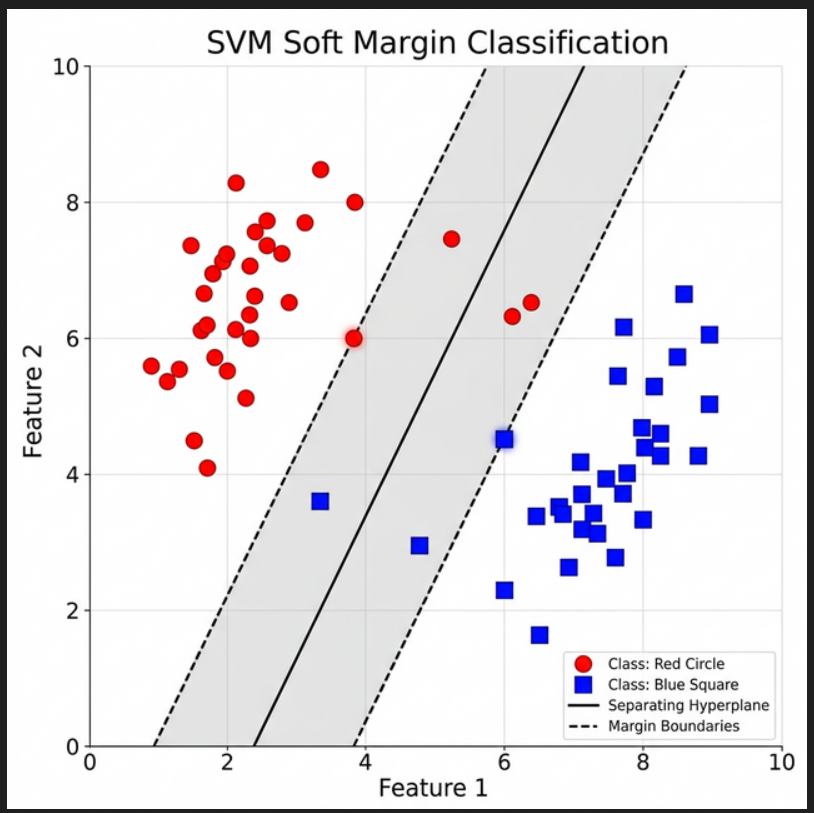

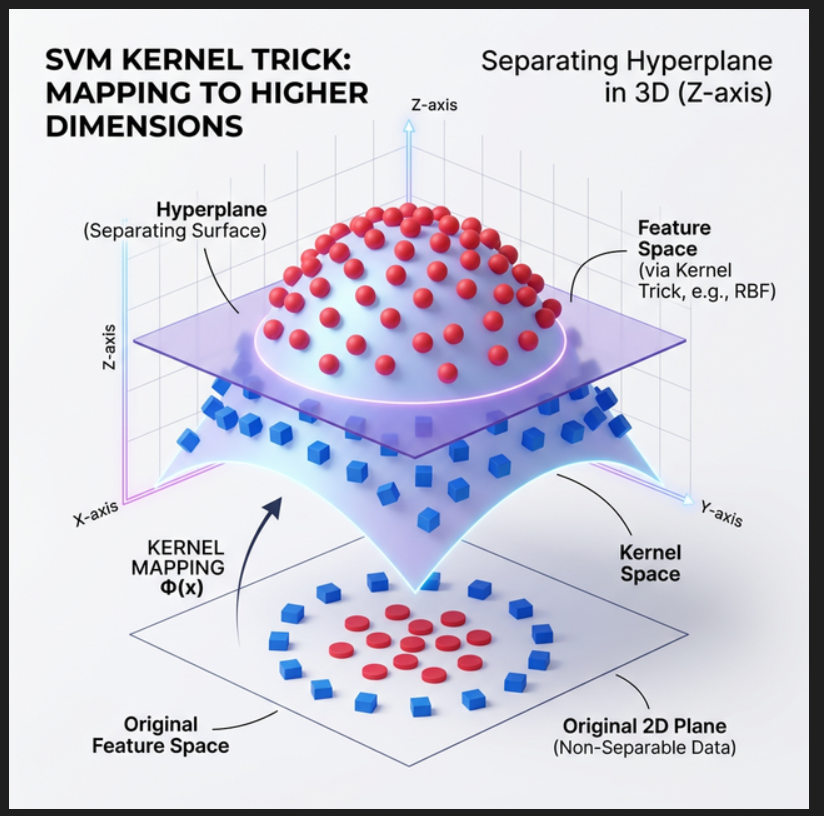




- SVM is robust to outliers
- Can also work in the case of non-linear data
- Can be used for both classification and regression problem

`Margin` is the distance btwn the positive and negative hyperplane.


# Support Vector Machine (SVM) In-Depth Guide

## Geometric Intuition of SVM

The core idea behind a Support Vector Machine (SVM) is finding the **best possible boundary** (called a hyperplane) to separate different classes of data.

### The Objective: Finding the Optimal Hyperplane
Imagine you have red circles and blue squares on a 2D graph. You could draw infinite lines to separate them. However, SVM looks for the **Optimal Separating Hyperplane**—the line that not only separates the classes but does so with the **maximum margin** (the widest possible street) between the two classes.

* **Hyperplane:** In 2D, it's a line. In 3D, it's a flat plane. In higher dimensions, it's a hyperplane.
* **Margin:** The distance between the hyperplane and the closest data points from either class. SVM tries to maximize this "street".
* **Support Vectors:** The specific data points that lie exactly on the edge of the margin. They are called "support" vectors because they are the only points that actually influence the position of the hyperplane. If you moved or deleted other points further away, the hyperplane wouldn't change.

### Hard Margin vs. Soft Margin
* **Hard Margin:** Assumes the data is perfectly separable without any errors. It strictly enforces that no point can be inside the margin.
* **Soft Margin:** Real-world data is messy and often overlaps. A soft margin allows some points to cross the margin (or even be misclassified) to get a more robust generalized boundary. This is controlled by the **Hyperparameter `C`**:
  * **Low `C`:** Wider margin, more misclassifications allowed (focuses on the big picture / prevents overfitting).
  * **High `C`:** Narrow margin, strictly penalizes misclassifications (can lead to overfitting).

### The Kernel Trick
What if the data is arranged in a circle and cannot be separated by a straight line? SVM uses the **Kernel Trick**. It mathematically projects the 2D data into a 3D space (making it curved or bell-shaped), finds a flat 2D plane to separate it there, and then projects it back. 
* Common Kernels: **Linear, Polynomial, RBF (Radial Basis Function)**.

---

## The Mathematics of SVM (Hard Margin)

Let's formally define the math behind finding this optimal line. 

### The Equation of the Hyperplane
Any straight line (hyperplane) can be written as:
$$ w^T x + b = 0 $$
Where:
* $w$ = The weight vector (perpendicular/normal to the hyperplane). This controls the orientation of the line.
* $x$ = The input feature vector (the data point).
* $b$ = The bias (the intercept). This shifts the line away from the origin.

### The Decision Rule
For any new data point $x_i$, our model predicts the class $y_i \in \{-1, 1\}$:
* If $w^T x_i + b \geq 1$, the prediction is Class **+1** (Positive Class)
* If $w^T x_i + b \leq -1$, the prediction is Class **-1** (Negative Class)

Notice the `1` and `-1`. These represent the boundaries of our "Margin". The support vectors lie exactly on $w^T x + b = 1$ and $w^T x + b = -1$.

### Maximizing the Margin
Through linear algebra, the total width of the margin (the distance from the +1 boundary to the -1 boundary) is exactly:
$$ \text{Margin Width} = \frac{2}{||w||} $$
To make the margin as **large as possible**, we need exactly to make $||w||$ as **small as possible**. 

### The Optimization Problem
Mathematically, minimizing $||w||$ is annoying because of the square root. So instead, we minimize $\frac{1}{2} ||w||^2$.

**The Final Mathematical Objective:**
$$ \text{Minimize:} \quad \frac{1}{2} ||w||^2 $$
$$ \text{Subject to the constraint:} \quad y_i (w^T x_i + b) \geq 1 \quad \text{for all } i $$
*(This constraint just mathematically says: "Make sure every point is correctly classified and outside the margin").*





## A Simple Mathematical Example

Let's solve a basic 2D problem to see how the math finds the line. 

Imagine we have two support vectors:

* **Positive Class ($y=1$):** Point $A = (2, 2)$
* **Negative Class ($y=-1$):** Point $B = (0, 0)$

We want to find $w = [w_1, w_2]$ and bias $b$ for the hyperplane that separates them.

**Step 1: Apply the constraint equation for both points.**

Since they are support vectors, they sit exactly on the margin boundaries:

1. For Point A $(2,2)$ where $y=1$:

   $$2w_1 + 2w_2 + b = 1$$

2. For Point B $(0,0)$ where $y=-1$:

   $$ 0w_1 + 0w_2 + b = -1 \implies \mathbf{b = -1} $$

**Step 2: Solve for $w$.**
Substitute $b = -1$ into the first equation:
$$ 2w_1 + 2w_2 - 1 = 1 $$
$$ 2w_1 + 2w_2 = 2 $$
$$ w_1 + w_2 = 1 $$

Since minimizing $||w||^2$ means minimizing $w_1^2 + w_2^2$, the smallest value occurs when $w_1$ and $w_2$ are equal to distribute the weight. 
Let $w_1 = 0.5$ and $w_2 = 0.5$.

So, our weight vector is $\mathbf{w = [0.5, 0.5]}$.

**Step 3: The Final Hyperplane Equation.**
Plug $w$ and $b$ back into the general hyperplane equation $w^T x + b = 0$:
$$ 0.5x_1 + 0.5x_2 - 1 = 0 $$
Multiply by 2 for simplicity:
$$ \mathbf{x_1 + x_2 - 2 = 0} $$

**Conclusion of Example:**
The line $x_1 + x_2 = 2$ perfectly bisects the space between $(0,0)$ and $(2,2)$. If you graph this, it's a diagonal line going through $(2,0)$ and $(0,2)$. The margin distance is $\frac{2}{\sqrt{0.5^2 + 0.5^2}} = \frac{2}{\sqrt{0.5}} \approx 2.82$. 
